In [8]:
from neuromodes.io import fetch_surf, fetch_map
from neuromodes import EigenSolver
from neuromodes.mesh import unmask_data
from nsbutils.plotting import plot_surf
import numpy as np
from importlib.resources import files
import matplotlib.pyplot as plt

In [11]:
# Setup
seed = 0
n_modes = 500
density = '32k'
hemi = 'L'

surf_path = files('neuromodes.data') / f'sp-human_tpl-fsLR_den-{density}_hemi-{hemi}_midthickness.surf.gii'

surf, medmask = fetch_surf(density=density, hemi=hemi)
map = fetch_map('fcgradient1')[medmask]
myelinmap = fetch_map('myelinmap')[medmask]

In [12]:
solver = EigenSolver(surf, mask=medmask).solve(n_modes, seed=seed)

C:\Users\ipop0003\neuromodes\neuromodes\eigen.py:779: UserWarning: NaN values detected in data, which may cause issues with computations.
  warn("NaN values detected in data, which may cause issues with computations.")
C:\Users\ipop0003\neuromodes\neuromodes\eigen.py:779: UserWarning: NaN values detected in data, which may cause issues with computations.
  warn("NaN values detected in data, which may cause issues with computations.")
C:\Users\ipop0003\neuromodes\neuromodes\eigen.py:779: UserWarning: NaN values detected in data, which may cause issues with computations.
  warn("NaN values detected in data, which may cause issues with computations.")
C:\Users\ipop0003\neuromodes\neuromodes\eigen.py:779: UserWarning: NaN values detected in data, which may cause issues with computations.
  warn("NaN values detected in data, which may cause issues with computations.")


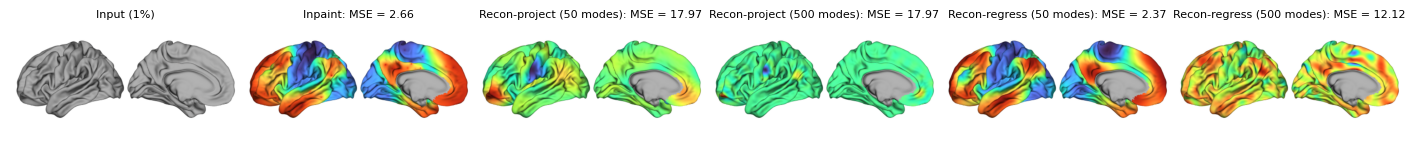

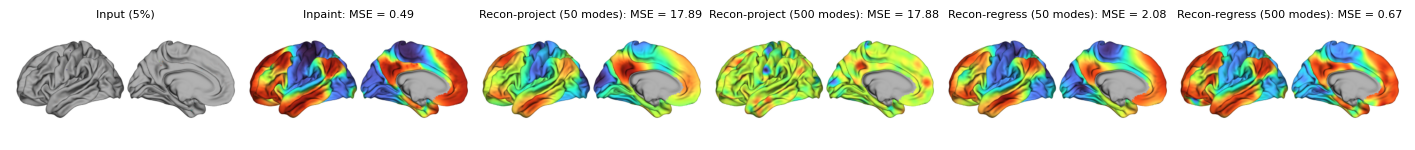

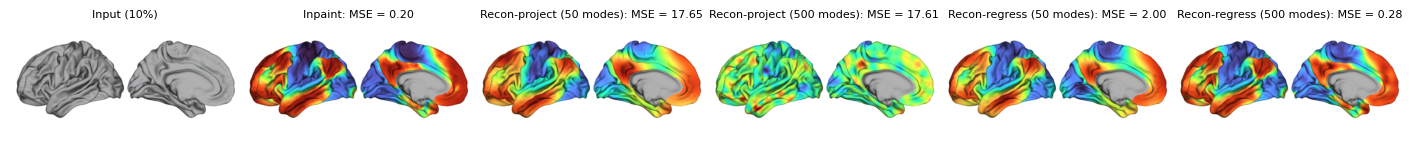

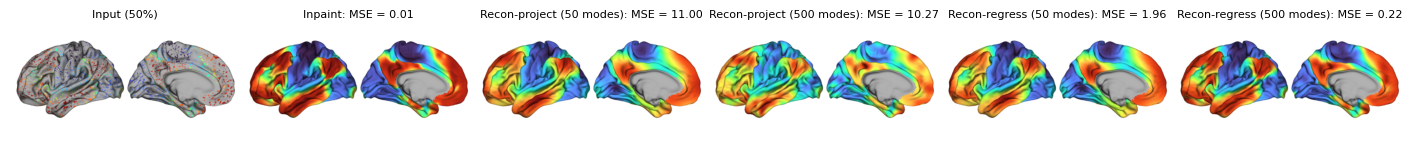

In [62]:
# Compare inpaint() and reconstruct-nan across different proportions of available data
props = [0.01, 0.05, 0.1, 0.5]
mode_counts = [50, 500]

for i, prop in enumerate(props):
    # make random mask
    random_mask = np.random.default_rng(seed).choice([True, False], size=map.shape, p=[prop, 1 - prop])
    map_masked_random = map.copy()
    map_masked_random[~random_mask] = np.nan

    # inpaint
    map_masked_random_inpaint = solver.inpaint(map_masked_random)
    mse_inpaint = (map - map_masked_random_inpaint) ** 2
    
    # reconstruct (project)
    beta = solver.decompose(map_masked_random, method='project', mode_counts=mode_counts)
    map_masked_random_project_50 = solver.emodes[:, :50] @ beta[0]
    map_masked_random_project_500 = solver.emodes[:, :500] @ beta[1]
    mse_project_50 = (map - map_masked_random_project_50) ** 2
    mse_project_500 = (map - map_masked_random_project_500) ** 2

    # reconstruct (regress)
    beta = solver.decompose(map_masked_random, method='regress', mode_counts=mode_counts)
    map_masked_random_regress_50 = solver.emodes[:, :50] @ beta[0]
    map_masked_random_regress_500 = solver.emodes[:, :500] @ beta[1]
    mse_regress_50 = (map - map_masked_random_regress_50) ** 2
    mse_regress_500 = (map - map_masked_random_regress_500) ** 2

    # plot
    all_maps = np.stack([
        map_masked_random, map_masked_random_inpaint,
        map_masked_random_project_50, map_masked_random_project_500,
        map_masked_random_regress_50, map_masked_random_regress_500
        ], axis=1)
    all_maps_unmasked = unmask_data(all_maps, medmask)
    labels = [
        f'Input ({prop*100:.0f}%)',
        f'Inpaint: MSE = {mse_inpaint.mean():.2f}',
        f'Recon-project (50 modes): MSE = {mse_project_50.mean():.2f}',
        f'Recon-project (500 modes): MSE = {mse_project_500.mean():.2f}',
        f'Recon-regress (50 modes): MSE = {mse_regress_50.mean():.2f}',
        f'Recon-regress (500 modes): MSE = {mse_regress_500.mean():.2f}'
        ]
    plot_surf(surf_path, all_maps_unmasked, labels=labels, label_kws = {'fontsize': 8})

C:\Users\ipop0003\neuromodes\neuromodes\eigen.py:779: UserWarning: NaN values detected in data, which may cause issues with computations.
  warn("NaN values detected in data, which may cause issues with computations.")


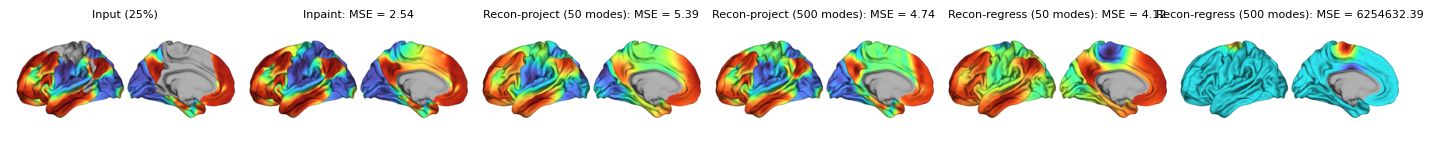

In [141]:
# Now try a pseudo-contiguous mask
prop = 0.25

map_masked_contig = map.copy()
map_masked_contig[:int(len(map) * prop)] = np.nan

# inpaint
map_masked_contig_inpaint = solver.inpaint(map_masked_contig)
mse_inpaint = np.mean((map - map_masked_contig_inpaint) ** 2)

# reconstruct (project)
beta = solver.decompose(map_masked_contig, method='project', mode_counts=mode_counts)
map_masked_contig_project_50 = solver.emodes[:, :50] @ beta[0]
map_masked_contig_project_500 = solver.emodes[:, :500] @ beta[1]
mse_project_50 = np.mean((map - map_masked_contig_project_50) ** 2)
mse_project_500 = np.mean((map - map_masked_contig_project_500) ** 2)

# reconstruct (regress)
beta = solver.decompose(map_masked_contig, method='regress', mode_counts=mode_counts)
map_masked_contig_regress_50 = solver.emodes[:, :50] @ beta[0]
map_masked_contig_regress_500 = solver.emodes[:, :500] @ beta[1]
mse_regress_50 = np.mean((map - map_masked_contig_regress_50) ** 2)
mse_regress_500 = np.mean((map - map_masked_contig_regress_500) ** 2)

# plot
all_maps = np.stack([
    map_masked_contig, map_masked_contig_inpaint,
    map_masked_contig_project_50, map_masked_contig_project_500,
    map_masked_contig_regress_50, map_masked_contig_regress_500
    ], axis=1)
all_maps_unmasked = unmask_data(all_maps, medmask)
labels = [
    f'Input ({prop*100:.0f}%)',
    f'Inpaint: MSE = {mse_inpaint.mean():.2f}',
    f'Recon-project (50 modes): MSE = {mse_project_50.mean():.2f}',
    f'Recon-project (500 modes): MSE = {mse_project_500.mean():.2f}',
    f'Recon-regress (50 modes): MSE = {mse_regress_50.mean():.2f}',
    f'Recon-regress (500 modes): MSE = {mse_regress_500.mean():.2f}'
    ]
plot_surf(surf_path, all_maps_unmasked, labels=labels, label_kws = {'fontsize': 8})

In [142]:
print(int(np.floor(mse_inpaint)*np.floor(mse_inpaint)*np.floor(mse_inpaint)*np.floor(mse_inpaint)*np.floor(mse_inpaint)*len(plt.AbstractContextManager.register.__dir__.__doc__.count.__eq__.__repr__.__name__[2:5])*(all_maps_unmasked.shape[1]-np.ones(solver.n_verts)[int(np.real(np.e**(1j * np.pi)))])*(all_maps_unmasked.shape[1]-np.ones(solver.n_verts)[int(np.real(np.e**(1j * np.pi)))])))

2400
